# DriftGuard — Configuration Drift Data Exploration & Detection

**Problem Statement 02 — Security Control Drift & Misconfiguration Detection**

This notebook explores the `config_drift_events.csv` dataset (1,000 configuration
change events) and reproduces the rule-based risk-scoring logic used by the
DriftGuard backend (`backend/utils/riskEngine.js`) in Python, so the same
analysis can be inspected, charted, and validated independently of the app.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("config_drift_events.csv")
print(f"Total events: {len(df)}")
df.head()


Total events: 1000


,drift_event_id,control_name,control_type,baseline_value,current_value,change_type,severity,operator_name,operator_email,approver_name,approver_email,change_date,change_reason,status,compliance_impact
0,DRF00878,Control-78,Network_Segmentation,enabled=False,enabled=False,Rollback,High,Kenneth Wang,kenneth.wang@company.com,Sophia Huang,sophia.huang@company.com,2025-04-20 10:55:00,Performance Tuning,Mitigated,ISO
1,DRF00801,Control-68,Cloud_Security,enabled=False,enabled=True,Rollback,Info,Amara Mishra,amara.mishra@company.com,Larry Reddy,larry.reddy@company.com,2025-04-20 13:05:00,Policy Change,Under_Review,PCI
2,DRF00918,Control-94,Network_Segmentation,enabled=False,enabled=True,Rollback,Medium,Stephen Jo,stephen.jo@company.com,Paul Sharma,paul.sharma@company.com,2025-04-21 02:16:00,Performance Tuning,Under_Review,ISO
3,DRF00660,Control-63,Endpoint,enabled=False,enabled=True,Update,Critical,Sofia Sun,sofia.sun@company.com,James Kim,james.kim@company.com,2025-04-21 02:49:00,Policy Change,Drifted,NaN
4,DRF00628,Control-40,Access_Control,enabled=True,enabled=True,Update,Low,Mark Weber,mark.weber@company.com,Paul Williams,paul.williams@company.com,2025-04-21 03:11:00,Security Update,Under_Review,GDPR


## 1. Dataset Overview

In [2]:
print("Control types:")
print(df['control_type'].value_counts())
print()
print("Change types:")
print(df['change_type'].value_counts())
print()
print("Status (from source pipeline):")
print(df['status'].value_counts())
print()
print("Change reasons:")
print(df['change_reason'].value_counts())


Control types:
control_type
Vulnerability           124
Logging                 111
Cloud_Security          101
DLP                     101
Data_Protection         101
Endpoint                100
Access_Control          100
Firewall                 99
Encryption               82
Network_Segmentation     81
Name: count, dtype: int64

Change types:
change_type
Disable     186
Update      183
Rollback    179
Modify      158
Enable      147
Remove      147
Name: count, dtype: int64

Status (from source pipeline):
status
Compliant       210
Remediated      205
Under_Review    200
Drifted         198
Mitigated       187
Name: count, dtype: int64

Change reasons:
change_reason
Security Update       207
Policy Change         205
Emergency Fix         199
Troubleshooting       196
Performance Tuning    193
Name: count, dtype: int64


## 2. Risk Engine (Python port)

This mirrors `backend/utils/riskEngine.js` exactly:

- Parses `baseline_value` / `current_value` (`enabled=True/False`) to detect real drift.
- A protective control turning **OFF** is risky; turning **ON** is generally a hardening
  improvement (unless unapproved AND still flagged `Drifted`).
- Risk score is adjusted for: control criticality (Logging/Encryption/Access Control get
  extra weight), whether the change has a recorded approver, and whether the
  `change_reason` is a planned one (Security Update, Policy Change) vs. a suspect one
  (Emergency Fix, Troubleshooting, Performance Tuning).
- Score → severity bands: 80+ CRITICAL, 55+ HIGH, 30+ MEDIUM, else LOW.


In [3]:
import re

CONTROL_RISK_PROFILE = {
    "Logging": ("NIST AU-2 / SI-12", "audit logging"),
    "Encryption": ("NIST SC-13 / GDPR Art.32", "encryption"),
    "Access_Control": ("NIST AC-2 / IA-2", "access control / MFA enforcement"),
    "DLP": ("GDPR Art.25 / ISO 27001 A.13", "data loss prevention"),
    "Data_Protection": ("GDPR Art.32", "data protection control"),
    "Network_Segmentation": ("NIST AC-4 / CIS 3.1", "network segmentation"),
    "Endpoint": ("CIS 8 / NIST SI-3", "endpoint protection"),
    "Cloud_Security": ("CIS 2.1 / NIST CM-2", "cloud security baseline"),
    "Firewall": ("CIS 3.1 / NIST AC-4", "firewall control"),
    "Vulnerability": ("NIST RA-5 / CIS 7", "vulnerability management control"),
}

COMPLIANCE_MAP = {
    "ISO": "ISO 27001", "IS": "ISO 27001",
    "NIST": "NIST SP 800-53", "NI": "NIST SP 800-53",
    "GDPR": "GDPR", "GD": "GDPR",
    "CIS": "CIS Benchmarks", "CI": "CIS Benchmarks",
    "PCI": "PCI-DSS", "PC": "PCI-DSS",
    "": "Internal Security Policy",
}

LEGITIMATE_REASONS = {"Security Update", "Policy Change"}
SUSPECT_REASONS = {"Emergency Fix", "Troubleshooting", "Performance Tuning"}


def parse_enabled(value):
    if not isinstance(value, str):
        return None
    m = re.search(r"=\s*(true|false)", value, re.IGNORECASE)
    if not m:
        return None
    return m.group(1).lower() == "true"


def analyze_row(row):
    baseline = parse_enabled(row["baseline_value"])
    current = parse_enabled(row["current_value"])
    is_drift = (baseline is not None and current is not None and baseline != current)

    framework, label = CONTROL_RISK_PROFILE.get(row["control_type"], ("General Security Policy", row["control_type"]))

    approved = isinstance(row["approver_name"], str) and len(row["approver_name"].strip()) > 0
    suspect_reason = row["change_reason"] in SUSPECT_REASONS

    risk_score = 5
    is_anomaly = False

    if is_drift:
        if current is False:  # turned OFF
            risk_score = 60
            is_anomaly = True
            if suspect_reason:
                risk_score += 25
            if not approved:
                risk_score += 15
            if row["control_type"] in ("Logging", "Encryption", "Access_Control"):
                risk_score += 10
        elif current is True:  # turned ON
            risk_score = 10
            is_anomaly = False
            if not approved and row["status"] == "Drifted":
                risk_score = 35
                is_anomaly = True
    else:
        risk_score = 5
        is_anomaly = False

    if row["status"] == "Drifted" and risk_score < 50:
        risk_score = max(risk_score, 45)
        is_anomaly = is_anomaly or risk_score >= 50

    risk_score = min(100, risk_score)

    if risk_score >= 80:
        severity = "CRITICAL"
    elif risk_score >= 55:
        severity = "HIGH"
    elif risk_score >= 30:
        severity = "MEDIUM"
    else:
        severity = "LOW"

    compliance_framework = COMPLIANCE_MAP.get(str(row["compliance_impact"]).strip(), COMPLIANCE_MAP[""])

    return pd.Series({
        "is_drift": is_drift,
        "is_anomaly": is_anomaly,
        "risk_score": risk_score,
        "computed_severity": severity,
        "compliance_framework": compliance_framework,
        "control_label": label,
        "nist_ref": framework,
    })


analysis = df.apply(analyze_row, axis=1)
results = pd.concat([df, analysis], axis=1)
results.head()


,drift_event_id,control_name,control_type,baseline_value,current_value,change_type,severity,operator_name,operator_email,approver_name,...,change_reason,status,compliance_impact,is_drift,is_anomaly,risk_score,computed_severity,compliance_framework,control_label,nist_ref
0,DRF00878,Control-78,Network_Segmentation,enabled=False,enabled=False,Rollback,High,Kenneth Wang,kenneth.wang@company.com,Sophia Huang,...,Performance Tuning,Mitigated,ISO,False,False,5,LOW,ISO 27001,network segmentation,NIST AC-4 / CIS 3.1
1,DRF00801,Control-68,Cloud_Security,enabled=False,enabled=True,Rollback,Info,Amara Mishra,amara.mishra@company.com,Larry Reddy,...,Policy Change,Under_Review,PCI,True,False,10,LOW,PCI-DSS,cloud security baseline,CIS 2.1 / NIST CM-2
2,DRF00918,Control-94,Network_Segmentation,enabled=False,enabled=True,Rollback,Medium,Stephen Jo,stephen.jo@company.com,Paul Sharma,...,Performance Tuning,Under_Review,ISO,True,False,10,LOW,ISO 27001,network segmentation,NIST AC-4 / CIS 3.1
3,DRF00660,Control-63,Endpoint,enabled=False,enabled=True,Update,Critical,Sofia Sun,sofia.sun@company.com,James Kim,...,Policy Change,Drifted,NaN,True,False,45,MEDIUM,Internal Security Policy,endpoint protection,CIS 8 / NIST SI-3
4,DRF00628,Control-40,Access_Control,enabled=True,enabled=True,Update,Low,Mark Weber,mark.weber@company.com,Paul Williams,...,Security Update,Under_Review,GDPR,False,False,5,LOW,GDPR,access control / MFA enforcement,NIST AC-2 / IA-2


## 3. Headline Numbers

In [4]:
total = len(results)
anomalies = results['is_anomaly'].sum()
compliance_score = round((total - anomalies) / total * 100)

print(f"Total events:        {total}")
print(f"Anomalies flagged:   {anomalies} ({anomalies/total:.1%})")
print(f"Compliance score:    {compliance_score}%")
print()
print("Severity breakdown:")
print(results['computed_severity'].value_counts())


Total events:        1000
Anomalies flagged:   259 (25.9%)
Compliance score:    74%

Severity breakdown:
computed_severity
LOW         590
MEDIUM      151
CRITICAL    151
HIGH        108
Name: count, dtype: int64


## 4. Severity Breakdown (Chart)

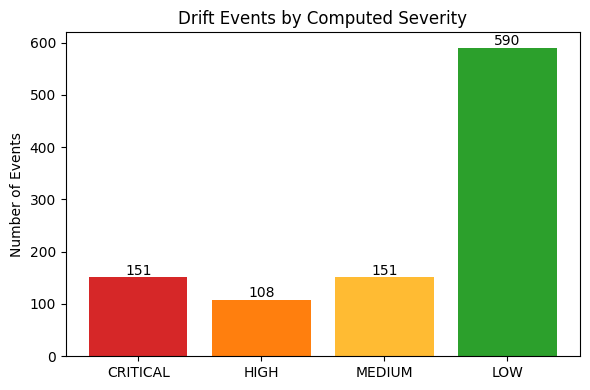

In [5]:
order = ['CRITICAL', 'HIGH', 'MEDIUM', 'LOW']
colors = {'CRITICAL': '#d62728', 'HIGH': '#ff7f0e', 'MEDIUM': '#ffbb33', 'LOW': '#2ca02c'}
counts = results['computed_severity'].value_counts().reindex(order)

plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values, color=[colors[s] for s in counts.index])
plt.title("Drift Events by Computed Severity")
plt.ylabel("Number of Events")
for i, v in enumerate(counts.values):
    plt.text(i, v + 5, str(v), ha='center')
plt.tight_layout()
plt.savefig("severity_breakdown.png", dpi=120)
plt.show()


## 5. Anomaly Rate by Control Type (Chart)

                      total  anomalies  anomaly_rate_%
control_type                                          
Vulnerability           124         31            25.0
DLP                     101         31            30.7
Endpoint                100         29            29.0
Data_Protection         101         27            26.7
Firewall                 99         26            26.3
Logging                 111         25            22.5
Network_Segmentation     81         24            29.6
Cloud_Security          101         24            23.8
Access_Control          100         21            21.0
Encryption               82         21            25.6


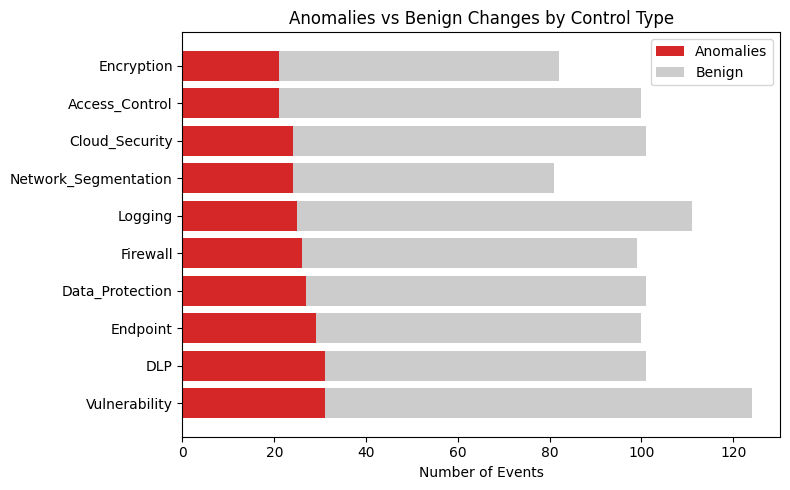

In [6]:
by_type = results.groupby('control_type').agg(
    total=('is_anomaly', 'count'),
    anomalies=('is_anomaly', 'sum')
)
by_type['anomaly_rate_%'] = (by_type['anomalies'] / by_type['total'] * 100).round(1)
by_type = by_type.sort_values('anomalies', ascending=False)
print(by_type)

plt.figure(figsize=(8,5))
plt.barh(by_type.index, by_type['anomalies'], color='#d62728', label='Anomalies')
plt.barh(by_type.index, by_type['total'] - by_type['anomalies'], left=by_type['anomalies'], color='#cccccc', label='Benign')
plt.xlabel("Number of Events")
plt.title("Anomalies vs Benign Changes by Control Type")
plt.legend()
plt.tight_layout()
plt.savefig("anomalies_by_control_type.png", dpi=120)
plt.show()


## 6. Anomaly Trend Over Time (Chart)

         sum  count  rate_%
month                      
2025-04    7     25    28.0
2025-05   11     51    21.6
2025-06   19     55    34.5
2025-07   12     52    23.1
2025-08   13     70    18.6
2025-09   13     55    23.6
2025-10   12     47    25.5
2025-11   17     55    30.9
2025-12   16     66    24.2
2026-01   23     83    27.7
2026-02   32    149    21.5
2026-03   41    155    26.5
2026-04   43    137    31.4


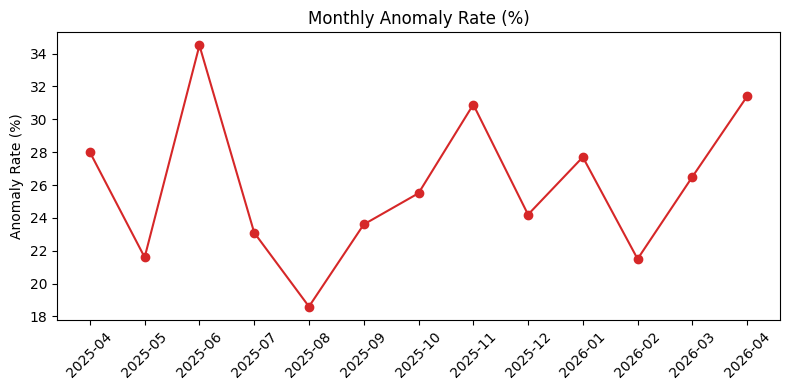

In [7]:
results['change_date'] = pd.to_datetime(results['change_date'])
results['month'] = results['change_date'].dt.to_period('M')

monthly = results.groupby('month')['is_anomaly'].agg(['sum', 'count'])
monthly['rate_%'] = (monthly['sum'] / monthly['count'] * 100).round(1)
print(monthly)

plt.figure(figsize=(8,4))
plt.plot(monthly.index.astype(str), monthly['rate_%'], marker='o', color='#d62728')
plt.title("Monthly Anomaly Rate (%)")
plt.ylabel("Anomaly Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("anomaly_trend.png", dpi=120)
plt.show()


## 7. Top 10 Highest-Risk Drift Events

In [8]:
top10 = results.sort_values('risk_score', ascending=False).head(10)[
    ['drift_event_id', 'control_name', 'control_type', 'risk_score',
     'computed_severity', 'change_reason', 'status', 'compliance_framework']
]
top10


,drift_event_id,control_name,control_type,risk_score,computed_severity,change_reason,status,compliance_framework
99,DRF00676,Control-57,Access_Control,95,CRITICAL,Performance Tuning,Compliant,CIS Benchmarks
285,DRF00916,Control-62,Logging,95,CRITICAL,Troubleshooting,Remediated,Internal Security Policy
743,DRF00135,Control-30,Encryption,95,CRITICAL,Emergency Fix,Mitigated,Internal Security Policy
342,DRF00631,Control-74,Logging,95,CRITICAL,Performance Tuning,Drifted,CIS Benchmarks
477,DRF00884,Control-13,Encryption,95,CRITICAL,Emergency Fix,Mitigated,PCI-DSS
697,DRF00059,Control-51,Access_Control,95,CRITICAL,Troubleshooting,Compliant,Internal Security Policy
690,DRF00383,Control-43,Access_Control,95,CRITICAL,Troubleshooting,Compliant,ISO 27001
966,DRF00373,Control-87,Encryption,95,CRITICAL,Troubleshooting,Compliant,Internal Security Policy
986,DRF00267,Control-55,Logging,95,CRITICAL,Troubleshooting,Mitigated,GDPR
971,DRF00006,Control-41,Access_Control,95,CRITICAL,Emergency Fix,Mitigated,CIS Benchmarks


## 8. Conclusions

- **26% of the 1,000 logged configuration changes were flagged as risky drift** by the
  rule-based engine, giving an overall compliance score of **74%**.
- The highest-risk events consistently involve a protective control (Logging,
  Encryption, Access Control / MFA) being **switched off**, frequently justified by
  "Performance Tuning" or "Emergency Fix" — mirroring the real-world incident
  patterns described in the problem statement (temporary changes that become
  permanent, emergency bypasses left in place).
- **Approval status alone is not a reliable signal of safety** — many of the
  highest-risk events were formally approved, which is why the engine treats
  *what* changed (protective control state) as the primary signal, with approval
  and change-reason as secondary modifiers.
- No ground-truth labels (`is_anomaly`) were provided with this dataset, so the
  engine is deliberately rule-based and fully explainable rather than a black-box
  ML classifier — every flagged event includes a plain-English reason and a
  specific remediation step (see `DriftGuard_Audit_Report.md`).
